In [170]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [171]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])

In [172]:
class CEDARSignature(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform

    def __len__(self):
        return 55 * 24

    def __getitem__(self, idx):
        sig_number = int(idx // 24) + 1
        sig_copy = int(idx % 24) + 1
        label = random.choice(["original", "forgeries"])
        random_copy = random.choice([i for i in range(1, 25) if i != sig_copy])

        anchor_path = os.path.join(self.root, f"full_org/original_{sig_number}_{sig_copy}.png")

        if label == "original":
            test_path = os.path.join(self.root, f"full_org/original_{sig_number}_{random_copy}.png")
        else:
            test_path = os.path.join(self.root, f"full_forg/forgeries_{sig_number}_{random_copy}.png")

        anchor_img = Image.open(anchor_path).convert("L")
        test_img = Image.open(test_path).convert("L")

        if self.transform:
            anchor_img = self.transform(anchor_img)
            test_img = self.transform(test_img)

        if label == "original":
            numeric_label = 1
        else:
            numeric_label = 0

        return anchor_img, test_img, numeric_label

In [161]:
dataset = CEDARSignature(root="../data/signatures", transform=transform)

train_len = int(0.8 * len(dataset))
test_len = len(dataset) - train_len

train_set, test_set = random_split(dataset, [train_len, test_len])

train_loader = DataLoader(train_set, batch_size=24, shuffle=True)
test_loader = DataLoader(test_set, batch_size=24, shuffle=False)

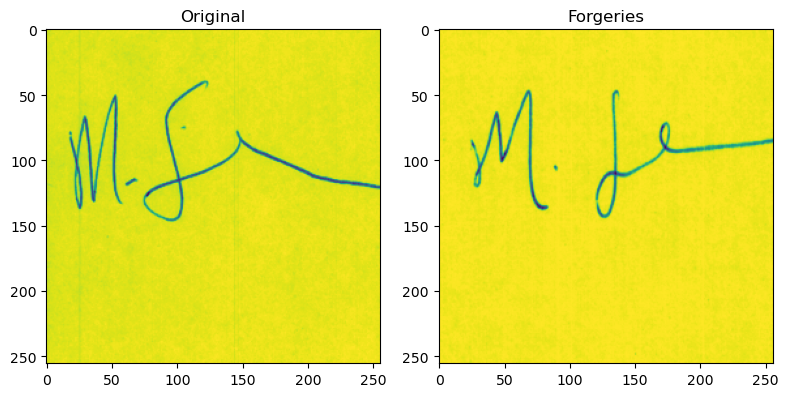

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

mean, std = 0.5, 0.5
anchor, test, label = next(iter(train_loader))
transformed_anchor = torch.squeeze(anchor[0] * std + mean, 0)
transformed_test = torch.squeeze(test[0] * std + mean, 0)

axes[0].imshow(transforms.ToPILImage()(transformed_anchor))
axes[0].set_title("Original")

axes[1].imshow(transforms.ToPILImage()(transformed_test))
axes[1].set_title("Positive" if label[0] == 1 else "Forgeries")

plt.tight_layout()
plt.show()

In [163]:
class CNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        x = self.layers(x)
        return x

class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedded_layer = nn.Sequential(
            CNNLayer(1, 16),
            CNNLayer(16, 32),
            CNNLayer(32, 64),
        )

        self.embedding_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )

    def forward(self, anchor, test):
        enc1 = self.embedded_layer(anchor)
        enc2 = self.embedded_layer(test)

        return self.embedding_head(enc1), self.embedding_head(enc2)

In [164]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, test, label):
        euclidean_distance = F.pairwise_distance(anchor, test)
        contras_loss = label * (euclidean_distance ** 2) + (1 - label) * (torch.clamp(self.margin - euclidean_distance, 0) ** 2)

        return contras_loss.mean()

In [165]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using {device}")

model = SiameseNetwork().to(device)
loss_function = ContrastiveLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
threshold = 0.5

Using mps


In [168]:
def train_epoch(model, train_loader, loss_function, optimizer, scheduler, threshold, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (anchors, tests, targets) in enumerate(train_loader):
        anchors, tests, targets = anchors.to(device), tests.to(device), targets.to(device)

        optimizer.zero_grad()
        emb1, emb2 = model(anchors, tests)
        loss = loss_function(emb1, emb2, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total += targets.size(0)

        with torch.no_grad():
            euclidean_dist = F.pairwise_distance(emb1, emb2)
            predicted = (euclidean_dist < threshold).float()
            correct += (predicted == targets).sum().item()

        if batch_idx % 8 == 0 and batch_idx > 0:
            print(f"train loss: {running_loss / 8:.3f} | train accuracy: {100 * correct / total:.1f}")
            running_loss = 0.0

    scheduler.step()

def evaluate(model, test_loader, threshold, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for anchors, tests, labels in test_loader:
            anchors, tests, labels = anchors.to(device), tests.to(device), labels.to(device)

            emb1, emb2 = model(anchors, tests)
            loss = loss_function(emb1, emb2, labels)
            euclidean_dist = F.pairwise_distance(emb1, emb2)
            predicted = (euclidean_dist < threshold).float() 

            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            running_loss += loss.item()

    return  running_loss / len(test_loader), 100 * correct / total

In [169]:
num_epoch = 5

for epoch in range(num_epoch):
    print(f"Epoch {epoch}") 
    train_epoch(model, train_loader, loss_function, optimizer, scheduler, threshold, device)
    running_loss, accuracy = evaluate(model, test_loader, threshold, device)
    print(f"val loss: {running_loss:.3f} | val accuracy: {accuracy:.1f}")

Epoch 0
train loss: 0.169 | train accuracy: 81.9
train loss: 0.097 | train accuracy: 87.5
train loss: 0.091 | train accuracy: 88.3
train loss: 0.113 | train accuracy: 88.3
train loss: 0.076 | train accuracy: 88.9
val loss: 0.092 | val accuracy: 86.7
Epoch 1
train loss: 0.112 | train accuracy: 86.6
train loss: 0.058 | train accuracy: 90.2
train loss: 0.052 | train accuracy: 91.8
train loss: 0.058 | train accuracy: 92.4
train loss: 0.083 | train accuracy: 92.1
val loss: 0.077 | val accuracy: 89.0
Epoch 2
train loss: 0.090 | train accuracy: 92.1
train loss: 0.067 | train accuracy: 90.9
train loss: 0.066 | train accuracy: 92.0
train loss: 0.071 | train accuracy: 91.9
train loss: 0.040 | train accuracy: 93.1
val loss: 0.051 | val accuracy: 96.6
Epoch 3
train loss: 0.056 | train accuracy: 96.3
train loss: 0.046 | train accuracy: 96.6
train loss: 0.069 | train accuracy: 96.2
train loss: 0.073 | train accuracy: 94.6
train loss: 0.064 | train accuracy: 94.7
val loss: 0.043 | val accuracy: 94.7


In [194]:
def visualization(model, threshold, num_images=2):
    fig, axes = plt.subplots(1, num_images, figsize=(8, 4))

    for anchors, tests, labels in test_loader:
        anchors, tests, labels = anchors.to(device), tests.to(device), labels.to(device)
        transformed_test = torch.squeeze(tests * std + mean, 0)
        total = 0

        batch_size = label.size(0)

        with torch.no_grad():
            emb1, emb2 = model(anchors, tests)
            euclidean_dist = F.pairwise_distance(emb1, emb2)
            predicted = (euclidean_dist < threshold).float()
        
        for i in range(batch_size):
            axes[i].imshow(transforms.ToPILImage()(transformed_test[i].squeeze(0)))
            axes[i].set_title(f"Original label: {"Valid" if labels[i] == 1.0 else "Not valid"} \n Predicted: {"Valid" if predicted[i] == 1.0 else "Not valid"}")
            total += 1

            if total == num_images:
                return 

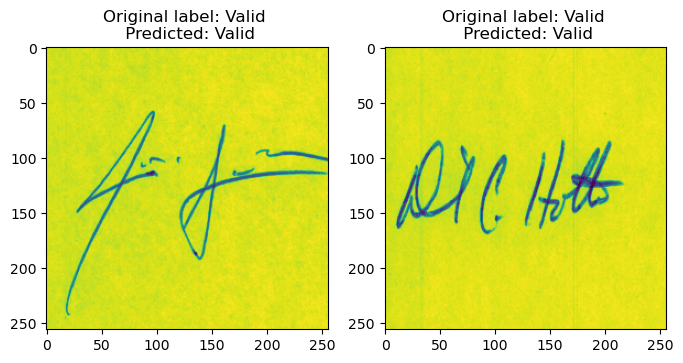

In [195]:
visualization(model, threshold, 2)